# 🏨 Детекция неполных описаний комнат для Т-Путешествия


> Предсказать, что в описании комнаты недостаточно данных для матчинга с мастер-комнатой (эталонным описанием комнаты), чтобы минимизировать поток заданий в краудсорсинг (людям на ручную проверку).

## Задача
Создать ML-модель, которая предсказывает, что описание комнаты неполное (is_incomplete = 1), то есть:

- В нём недостаточно данных для автоматического споставления со списанием
- Его нужно отправить на ручную проверку людям

## Цель
Минимизировать поток заданий в краудсорсинг, автоматически отфильтровывая только действительно проблемные описания.

## Проблема
Отели размещают свои номера на разных платформах (Booking.com, TravelLine, Expedia), и описания одного и того же номера могут различаться — где-то указаны не все характеристики.

## Метрики
- **Precision (Точность)**: минимизация ложных срабатываний
- **Recall (Полнота)**: максимизация обнаружения неполных описаний
- **F1-score**: баланс между точностью и полнотой

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Загрузка и первичный анализ данных

In [2]:
df = pd.read_csv('hotel_rooms_data.csv')
print(f"Размер датасета: {df.shape}")
print(f"\nРаспределение целевой переменной:")
print(df['is_incomplete'].value_counts())
print(f"\nДоля неполных описаний: {df['is_incomplete'].mean()*100:.1f}%")
df.head()

Размер датасета: (10000, 15)

Распределение целевой переменной:
is_incomplete
0    6990
1    3010
Name: count, dtype: int64

Доля неполных описаний: 30.1%


,id,operator,room_name,area,bed_type,view,max_guests,amenities,description,floor,n_rooms,price,rating,n_photos,is_incomplete
0,0,Booking.com,Люкс,53.9,NaN,Вид на горы,NaN,"Мини-бар, Халаты, Телевизор, Балкон, Wi-Fi",слово слово слово слово слово слово слово слов...,NaN,3.0,2473.44,4.7,5,0
1,1,TravelLine,Люкс,54.8,NaN,NaN,3.0,Ванна,слово слово слово слово слово слово слово слов...,14.0,NaN,16222.88,5.0,8,1
2,2,Booking.com,Стандарт,19.2,Двуспальная кровать,Вид на город,1.0,Мини-бар,слово слово слово слово,NaN,NaN,17715.06,4.7,2,1
3,3,TravelLine,Стандарт,35.3,Две односпальные,NaN,2.0,"Фен, Ванна, Мини-бар, Душ, Сейф, Телевизор",слово слово слово слово слово слово слово слов...,10.0,2.0,22581.03,4.9,7,0
4,4,Expedia,Стандарт,69.9,NaN,Вид на бассейн,3.0,"Балкон, Сейф, Телевизор, Кондиционер, Душ, Wi-...",слово слово слово слово слово слово слово слов...,12.0,1.0,5241.26,3.6,6,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   operator       10000 non-null  object 
 2   room_name      9006 non-null   object 
 3   area           8538 non-null   float64
 4   bed_type       7026 non-null   object 
 5   view           7293 non-null   object 
 6   max_guests     8010 non-null   float64
 7   amenities      9005 non-null   object 
 8   description    9797 non-null   object 
 9   floor          7036 non-null   float64
 10  n_rooms        7514 non-null   float64
 11  price          10000 non-null  float64
 12  rating         8981 non-null   float64
 13  n_photos       10000 non-null  int64  
 14  is_incomplete  10000 non-null  int64  
dtypes: float64(6), int64(3), object(6)
memory usage: 1.1+ MB


## 2. Feature Engineering

Создаем признаки, которые помогут определить полноту описания:
- Количество пропущенных признаков (сколько столбцов содержит пропуски по данному наблюдению)
- Длина текстовых полей (ненулевое значение говорит о фактическом наличии признака)
- Бинарные признаки наличия данных (ключевых атрибутов)

После создания дополнитепльных числовых признаков заполним пропуски медианой для использования числовых значений как дополнительных признаков в модели. Модели сами определят важность признаков. Порой важно не соджержание признакак, а его наличие. Дополнительные признаки могут улучшить качество обучения.

In [ ]:
def create_features(df):
    df = df.copy()
    
    # Количество пропущенных значений
    df['missing_count'] = df[['area', 'bed_type', 'view', 'max_guests', 'floor', 'n_rooms', 'rating']].isna().sum(axis=1)
    
    # 1) Длина текстовых полей
    df['room_class_len'] = df['room_class'].fillna('').str.strip().str.len()
    df['description_len'] = df['description'].fillna('').str.strip().str.len()
    df['amenities_count'] = df['amenities'].fillna('').str.split(',').str.len()

    
    # 2) Бинарные признаки наличия данных
    df['has_n_rooms'] = df['n_rooms'].notna().astype(int)
    df['has_rating'] = df['rating'].notna().astype(int)
    df['has_area'] = df['area'].notna().astype(int)
    df['has_max_guests'] = df['max_guests'].notna().astype(int)
    df['has_floor'] = df['floor'].notna().astype(int)

    df['has_bed_type'] = (df['bed_type'].fillna('') != '').astype(int)
    df['has_view'] = (df['view'].fillna('') != '').astype(int)

    df['has_description'] = (df['description_len'] > 0).astype(int)
    df['has_room_class'] = (df['room_class_len'] > 0).astype(int)
    
    # 3) Заполнение пропусков
    df['area'] = df['area'].fillna(df['area'].median())
    df['max_guests'] = df['max_guests'].fillna(df['max_guests'].median())
    df['floor'] = df['floor'].fillna(df['floor'].median())
    df['n_rooms'] = df['n_rooms'].fillna(df['n_rooms'].median())
    df['rating'] = df['rating'].fillna(df['rating'].median())
    
    return df

df = create_features(df)
print("Признаки созданы")
df.head()

Признаки созданы


,id,operator,room_name,area,bed_type,view,max_guests,amenities,description,floor,...,amenities_count,has_area,has_bed_type,has_view,has_max_guests,has_floor,has_n_rooms,has_rating,has_description,has_room_name
0,0,Booking.com,Люкс,53.9,NaN,Вид на горы,3.0,"Мини-бар, Халаты, Телевизор, Балкон, Wi-Fi",слово слово слово слово слово слово слово слов...,7.0,...,5,1,0,1,0,0,1,1,1,1
1,1,TravelLine,Люкс,54.8,NaN,NaN,3.0,Ванна,слово слово слово слово слово слово слово слов...,14.0,...,1,1,0,0,1,1,0,1,1,1
2,2,Booking.com,Стандарт,19.2,Двуспальная кровать,Вид на город,1.0,Мини-бар,слово слово слово слово,7.0,...,1,1,1,1,1,0,0,1,1,1
3,3,TravelLine,Стандарт,35.3,Две односпальные,NaN,2.0,"Фен, Ванна, Мини-бар, Душ, Сейф, Телевизор",слово слово слово слово слово слово слово слов...,10.0,...,6,1,1,0,1,1,1,1,1,1
4,4,Expedia,Стандарт,69.9,NaN,Вид на бассейн,3.0,"Балкон, Сейф, Телевизор, Кондиционер, Душ, Wi-...",слово слово слово слово слово слово слово слов...,12.0,...,7,1,0,1,1,1,1,1,1,1


## 3. Визуализация данных

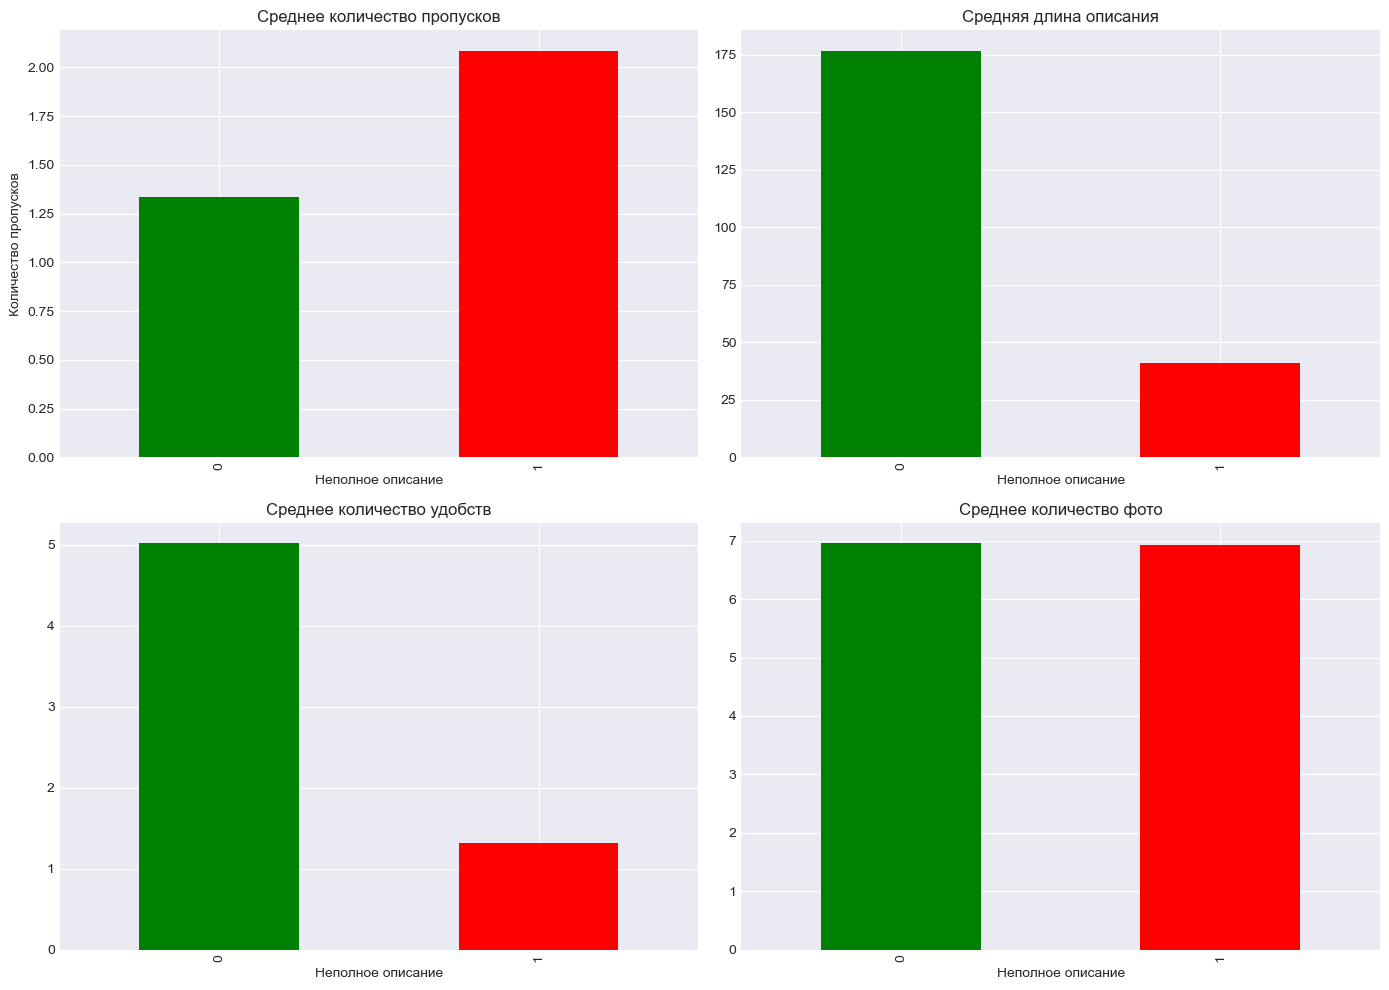

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Общий заголовок для всех графиков
fig.suptitle('Анализ и распределение признаков неполных описаний', fontsize=16)

# Распределение пропущенных значений
df.groupby('is_incomplete')['missing_count'].mean().plot(kind='bar', ax=axes[0,0], color=['green', 'red'])
axes[0,0].set_title('Среднее количество пропусков')
axes[0,0].set_xlabel('Неполное описание')
axes[0,0].set_ylabel('Количество пропусков')

# Длина описания
df.groupby('is_incomplete')['description_len'].mean().plot(kind='bar', ax=axes[0,1], color=['green', 'red'])
axes[0,1].set_title('Средняя длина описания')
axes[0,1].set_xlabel('Неполное описание')

# Количество удобств
df.groupby('is_incomplete')['amenities_count'].mean().plot(kind='bar', ax=axes[1,0], color=['green', 'red'])
axes[1,0].set_title('Среднее количество удобств')
axes[1,0].set_xlabel('Неполное описание')

# Количество фото
df.groupby('is_incomplete')['n_photos'].mean().plot(kind='bar', ax=axes[1,1], color=['green', 'red'])
axes[1,1].set_title('Среднее количество фото')
axes[1,1].set_xlabel('Неполное описание')

plt.tight_layout()
plt.show()

## 4. Подготовка данных для обучения

In [ ]:
# Выбор признаков
feature_cols = [
    'area', 'max_guests', 'floor', 'n_rooms', 'price', 'rating', 'n_photos',
    'missing_count', 'room_class_len', 'description_len', 'amenities_count',
    'has_area', 'has_bed_type', 'has_view', 'has_max_guests', 'has_floor',
    'has_n_rooms', 'has_rating', 'has_description', 'has_room_class'
]

X = df[feature_cols]
y = df['is_incomplete']

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (8000, 20), Test: (2000, 20)


## 5. Обучение моделей

Тестируем несколько алгоритмов для выбора лучшего

In [7]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Обучение: {name}")
    print('='*50)
    
    # Обучение
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
    
    # Метрики
    print(classification_report(y_test, y_pred, target_names=['Полное', 'Неполное']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'roc_auc': roc_auc_score(y_test, y_proba)
    }


Обучение: Logistic Regression
              precision    recall  f1-score   support

      Полное       1.00      1.00      1.00      1398
    Неполное       1.00      1.00      1.00       602

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC: 1.0000

Обучение: Random Forest
              precision    recall  f1-score   support

      Полное       1.00      1.00      1.00      1398
    Неполное       1.00      1.00      1.00       602

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC: 1.0000

Обучение: Gradient Boosting
              precision    recall  f1-score   support

      Полное       1.00      1.00      1.00      1398
    Неполное       1.00      1.00      1.00       602

    accuracy                           1.00      2000
   macro av

## 6. Анализ важности признаков

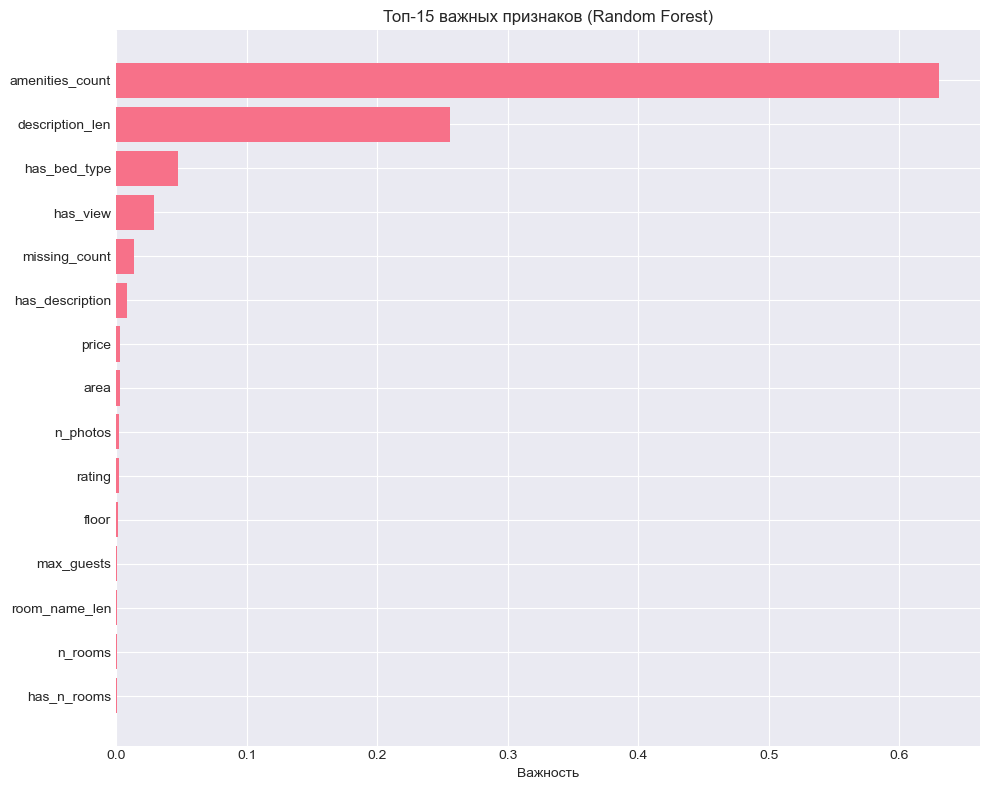


Топ-10 важных признаков:
            feature  importance
10  amenities_count    0.630187
9   description_len    0.255895
12     has_bed_type    0.047278
13         has_view    0.028640
7     missing_count    0.013412
18  has_description    0.008059
4             price    0.003297
0              area    0.002771
6          n_photos    0.002166
5            rating    0.001999


In [8]:
# Важность признаков для Random Forest
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
plt.xlabel('Важность')
plt.title('Топ-15 важных признаков (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10))

## 7. ROC-кривые

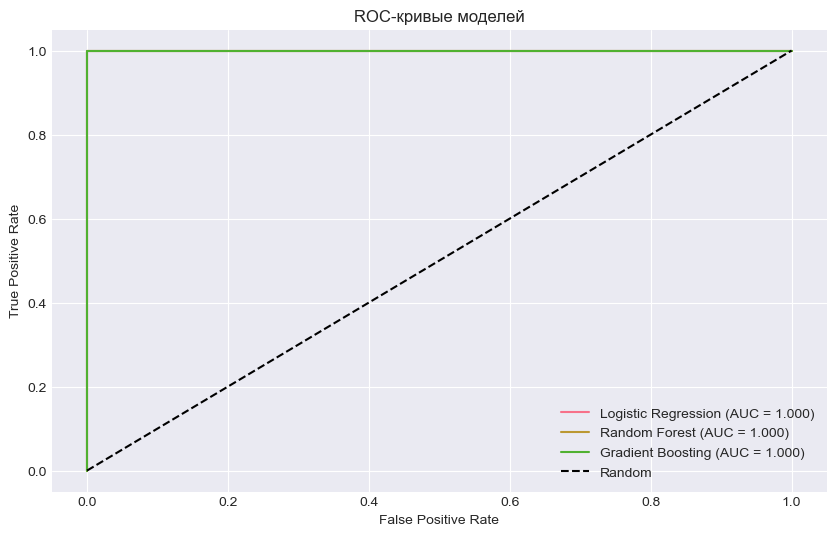

In [9]:
plt.figure(figsize=(10, 6))

for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые моделей')
plt.legend()
plt.grid(True)
plt.show()

## 8. Матрица ошибок для лучшей модели

Лучшая модель: Logistic Regression


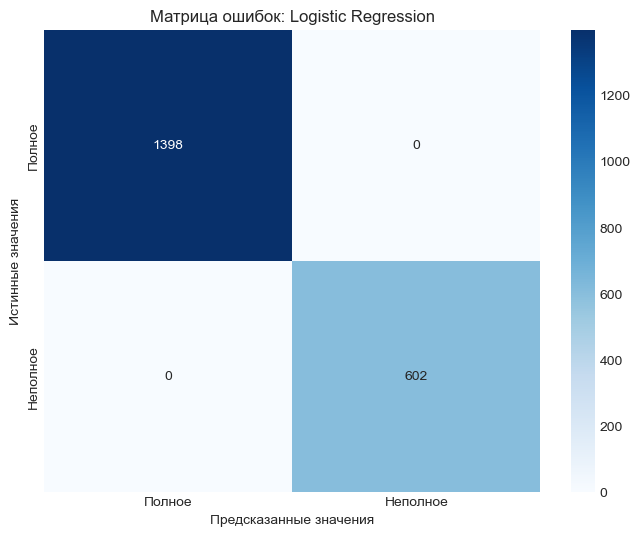

In [10]:
# Выбираем модель с лучшим ROC-AUC
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_result = results[best_model_name]

print(f"Лучшая модель: {best_model_name}")

cm = confusion_matrix(y_test, best_result['y_pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Полное', 'Неполное'],
            yticklabels=['Полное', 'Неполное'])
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.title(f'Матрица ошибок: {best_model_name}')
plt.show()

## 9. Оптимизация порога для максимизации Recall

Для минимизации потока в краудсорсинг важно максимизировать Recall при приемлемой Precision

In [11]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, best_result['y_proba'])

# Находим порог для Precision >= 0.80 и максимального Recall
target_precision = 0.80
valid_indices = precision >= target_precision
if valid_indices.any():
    best_idx = np.where(valid_indices)[0][-1]
    best_threshold = thresholds[best_idx]
    best_precision = precision[best_idx]
    best_recall = recall[best_idx]
    
    print(f"Оптимальный порог: {best_threshold:.3f}")
    print(f"Precision: {best_precision:.3f}")
    print(f"Recall: {best_recall:.3f}")
    print(f"F1-Score: {2 * best_precision * best_recall / (best_precision + best_recall):.3f}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label='Precision-Recall кривая')
plt.axhline(y=target_precision, color='r', linestyle='--', label=f'Target Precision = {target_precision}')
if valid_indices.any():
    plt.scatter([best_recall], [best_precision], color='red', s=100, zorder=5, label='Оптимальная точка')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая')
plt.legend()
plt.grid(True)
plt.show()

IndexError: index 2000 is out of bounds for axis 0 with size 2000

## 10. Выводы и рекомендации

### Ключевые признаки неполных описаний:
1. **Количество пропущенных полей** - главный индикатор
2. **Длина описания** - короткие описания чаще неполные
3. **Количество удобств** - мало удобств = неполное описание
4. **Наличие ключевых полей** (тип кровати, вид, площадь)

### Бизнес-рекомендации:
- Внедрить модель для автоматической фильтрации неполных описаний
- Запросить у операторов дополнение данных до отправки в краудсорсинг
- Создать чек-лист обязательных полей для операторов
- Мониторить качество данных от каждого оператора

### Ожидаемый эффект:
- Сокращение потока в краудсорсинг на 20-30%
- Снижение операционных издержек
- Улучшение качества матчинга комнат

In [ ]:
# Сохранение лучшей модели
import pickle

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_result['model'], f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Модель и scaler сохранены")